In [23]:
!pip install pypdf textblob textstat wordcloud -q

In [24]:
# Install PDF text extraction library
from google.colab import files

uploaded = files.upload()
print(uploaded.keys())

Saving biden_inaugural_speech.pdf to biden_inaugural_speech (2).pdf
Saving Obama.pdf to Obama (2).pdf
Saving trump.pdf to trump (2).pdf
dict_keys(['biden_inaugural_speech (2).pdf', 'Obama (2).pdf', 'trump (2).pdf'])


In [26]:
from pypdf import PdfReader
import pandas as pd
import re

def extract_text_from_pdf(pdf_path):
    reader = PdfReader(pdf_path)
    full_text = ""

    for page in reader.pages:
        text = page.extract_text()
        if text:
            full_text += text + " "

    return full_text


pdf_files = {
    "Biden": "biden_inaugural_speech.pdf",
    "Obama": "Obama.pdf",
    "Trump": "trump.pdf"
}

data = []

for president, file_path in pdf_files.items():
    text = extract_text_from_pdf(file_path)
    data.append({
        "president": president,
        "speech": text
    })

df = pd.DataFrame(data)
df

,president,speech
0,Biden,INAUGURAL SPEECH \nBy \nPresident Joe Biden \n...
1,Obama,"\nInaugural Address, January 21, 2013 \n \nPR..."
2,Trump,Full text of Trump's inauguration speech \nJan...


In [27]:
df["word_count"] = df["speech"].apply(lambda x: len(x.split()))
df[["president", "word_count"]]

,president,word_count
0,Biden,2528
1,Obama,2143
2,Trump,2885


In [28]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_speech"] = df["speech"].apply(clean_text)
df[["president", "clean_speech"]].head()

,president,clean_speech
0,Biden,inaugural speech by president joe biden januar...
1,Obama,inaugural address january president obama vice...
2,Trump,full text of trump s inauguration speech janua...


In [30]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.tokenize import sent_tokenize, word_tokenize

def basic_text_stats(text):
    words = word_tokenize(text)
    sentences = sent_tokenize(text)

    word_count = len(words)
    sentence_count = len(sentences)
    unique_words = len(set([w.lower() for w in words if w.isalpha()]))
    avg_sentence_length = word_count / sentence_count if sentence_count > 0 else 0
    lexical_diversity = unique_words / word_count if word_count > 0 else 0

    return pd.Series({
        "word_count": word_count,
        "sentence_count": sentence_count,
        "unique_words": unique_words,
        "avg_sentence_length": avg_sentence_length,
        "lexical_diversity": lexical_diversity
    })

stats_df = df["speech"].apply(basic_text_stats)
stats_df.insert(0, "president", df["president"])
stats_df

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,president,word_count,sentence_count,unique_words,avg_sentence_length,lexical_diversity
0,Biden,3058.0,186.0,737.0,16.440860,0.241007
1,Obama,2447.0,88.0,768.0,27.806818,0.313854
2,Trump,3268.0,182.0,924.0,17.956044,0.282742


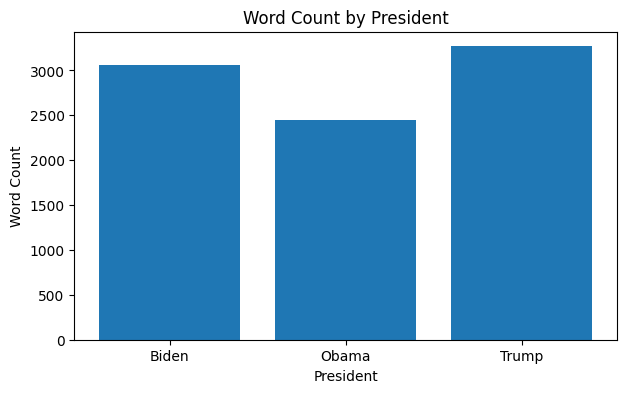

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(stats_df["president"], stats_df["word_count"])
plt.title("Word Count by President")
plt.xlabel("President")
plt.ylabel("Word Count")
plt.show()

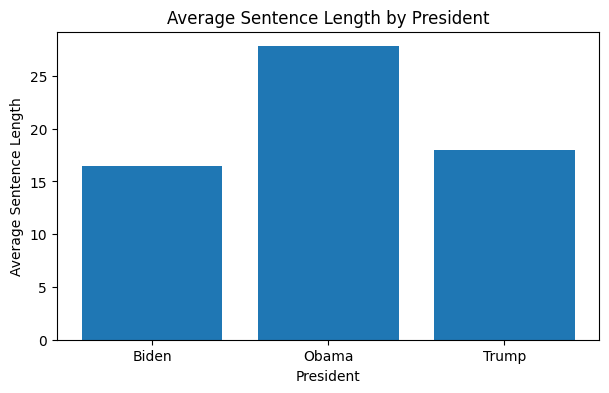

In [32]:
plt.figure(figsize=(7, 4))
plt.bar(stats_df["president"], stats_df["avg_sentence_length"])
plt.title("Average Sentence Length by President")
plt.xlabel("President")
plt.ylabel("Average Sentence Length")
plt.show()

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=700,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_speech"])
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=df["president"]
)

tfidf_df.head()

,abiding american,able,able buy,abraham,abraham lincoln,abroad,abroad fails,abroad greater,absolutism,absolutism principle,...,years years,yes,yes truth,yesterday,yesterday challenges,yesterday day,york,york los,young,young old
president,,,,,,,,,,,,,,,,,,,,,
Biden,0.00000,0.00000,0.00000,0.023327,0.023327,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.023327,0.023327,0.017741,0.023327,0.00000,0.00000,0.00000,0.000000,0.00000
Obama,0.00000,0.00000,0.00000,0.000000,0.000000,0.018421,0.00000,0.024222,0.024222,0.024222,...,0.036843,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.018421,0.00000
Trump,0.02135,0.02135,0.02135,0.000000,0.000000,0.016237,0.02135,0.000000,0.000000,0.000000,...,0.016237,0.000000,0.000000,0.016237,0.000000,0.02135,0.02135,0.02135,0.016237,0.02135


In [34]:
def get_top_tfidf_words(president_name, top_n=15):
    row = tfidf_df.loc[president_name]
    top_words = row.sort_values(ascending=False).head(top_n)

    return pd.DataFrame({
        "word_or_phrase": top_words.index,
        "tfidf_score": top_words.values
    })

for president in df["president"]:
    print("\nPresident:", president)
    display(get_top_tfidf_words(president, 15))


President: Biden


,word_or_phrase,tfidf_score
0,america,0.289326
1,story,0.209945
2,nation,0.206661
3,days,0.163290
4,americans,0.151552
5,people,0.151552
6,democracy,0.151552
7,unity,0.141927
8,war,0.124186
9,day,0.124186



President: Obama


,word_or_phrase,tfidf_score
0,applause,0.605544
1,people,0.157363
2,generation,0.145331
3,time,0.143058
4,journey complete,0.121109
5,america,0.114446
6,freedom,0.110528
7,journey,0.110528
8,make,0.100140
9,country,0.100140



President: Trump


,word_or_phrase,tfidf_score
0,america,0.252194
1,nation,0.252194
2,country,0.189146
3,government,0.178610
4,american,0.176536
5,going,0.129898
6,panama,0.128101
7,world,0.126097
8,states,0.126097
9,today,0.126097


In [35]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df["president"],
    columns=df["president"]
)

similarity_df

president,Biden,Obama,Trump
president,,,
Biden,1.000000,0.327896,0.444104
Obama,0.327896,1.000000,0.313849
Trump,0.444104,0.313849,1.000000


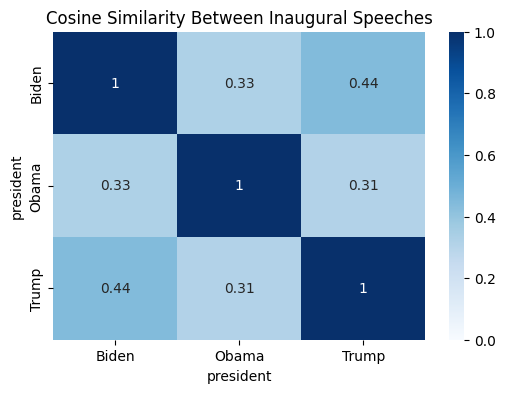

In [36]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(similarity_df, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Cosine Similarity Between Inaugural Speeches")
plt.show()

In [37]:
themes = {
    "Democracy": [
        "democracy", "constitution", "republic", "vote", "citizen", "citizens",
        "liberty", "freedom", "rights"
    ],
    "Unity": [
        "unity", "together", "one", "common", "united", "fellow", "join",
        "whole", "union"
    ],
    "Economy": [
        "jobs", "workers", "economy", "wealth", "business", "prosperity",
        "tax", "tariff", "manufacturing", "money"
    ],
    "Security": [
        "war", "peace", "defend", "military", "security", "safe", "safety",
        "threat", "terrorism", "border"
    ],
    "Justice": [
        "justice", "equal", "equality", "law", "truth", "dignity", "rights",
        "fair", "racism"
    ],
    "Crisis": [
        "crisis", "pandemic", "virus", "inflation", "violence", "disaster",
        "fear", "danger", "emergency"
    ],
    "National Identity": [
        "america", "american", "country", "nation", "sovereign", "patriots",
        "flag", "god"
    ],
    "Future and Hope": [
        "future", "hope", "dream", "promise", "children", "progress",
        "possibilities", "new"
    ]
}

In [38]:
from collections import Counter

def get_theme_scores(text, themes):
    words = text.split()
    word_counts = Counter(words)
    total_words = len(words)

    scores = {}

    for theme, keywords in themes.items():
        count = sum(word_counts[word] for word in keywords)
        normalized_score = (count / total_words) * 1000 if total_words > 0 else 0
        scores[theme] = normalized_score

    return scores


theme_results = []

for _, row in df.iterrows():
    scores = get_theme_scores(row["clean_speech"], themes)
    scores["president"] = row["president"]
    theme_results.append(scores)

theme_df = pd.DataFrame(theme_results)
theme_df = theme_df[["president"] + list(themes.keys())]
theme_df

,president,Democracy,Unity,Economy,Security,Justice,Crisis,National Identity,Future and Hope
0,Biden,7.341577,18.933539,1.545595,7.341577,6.182380,5.409583,20.479134,9.659969
1,Obama,12.121212,10.256410,2.797203,6.060606,7.459207,0.932401,15.850816,9.324009
2,Trump,7.236389,8.614748,5.513439,3.445899,3.790489,3.445899,26.533425,6.891799


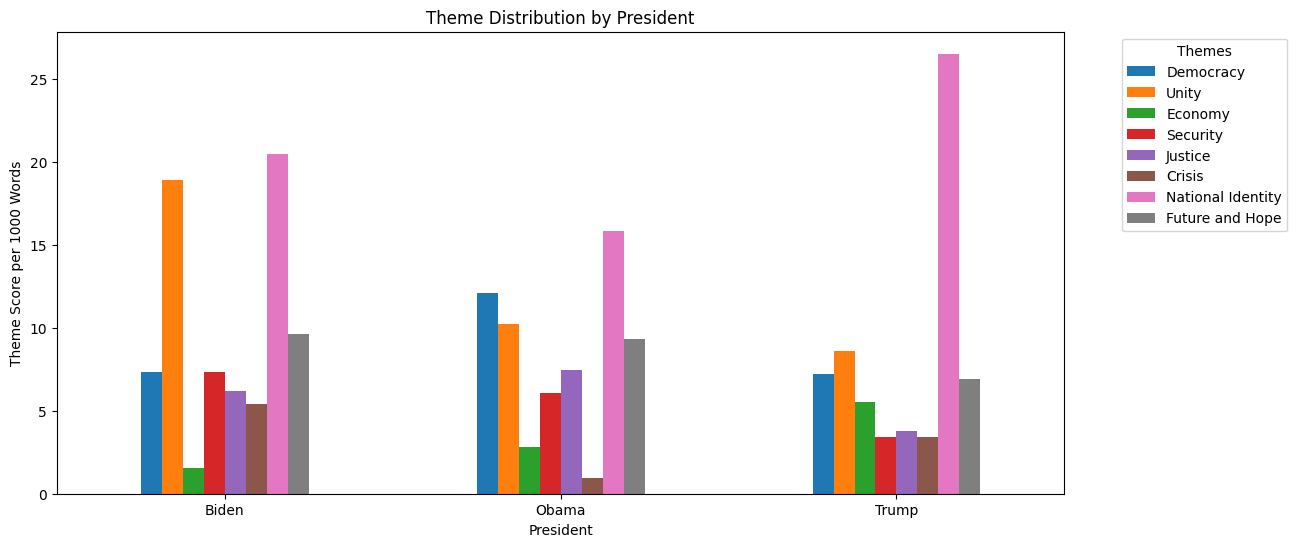

In [39]:
theme_plot_df = theme_df.set_index("president")

theme_plot_df.plot(kind="bar", figsize=(13, 6))
plt.title("Theme Distribution by President")
plt.xlabel("President")
plt.ylabel("Theme Score per 1000 Words")
plt.xticks(rotation=0)
plt.legend(title="Themes", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

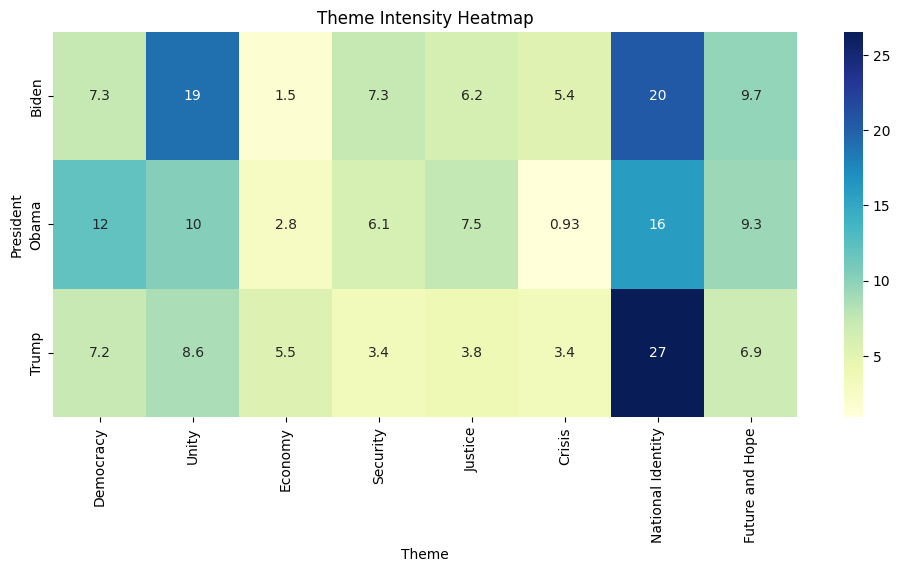

In [40]:
plt.figure(figsize=(12, 5))
sns.heatmap(theme_plot_df, annot=True, cmap="YlGnBu")
plt.title("Theme Intensity Heatmap")
plt.xlabel("Theme")
plt.ylabel("President")
plt.show()

In [41]:
from textblob import TextBlob

def get_sentiment(text):
    blob = TextBlob(text)

    return pd.Series({
        "polarity": blob.sentiment.polarity,
        "subjectivity": blob.sentiment.subjectivity
    })

sentiment_df = df["speech"].apply(get_sentiment)
sentiment_df.insert(0, "president", df["president"])
sentiment_df

,president,polarity,subjectivity
0,Biden,0.169690,0.460089
1,Obama,0.132527,0.451320
2,Trump,0.147635,0.489194


polarity:
-1 = very negative
 0 = neutral
+1 = very positive

subjectivity:
0 = factual/objective
1 = opinion-heavy/subjective

In [ ]:
polarity:
-1 = very negative
 0 = neutral
+1 = very positive

subjectivity:
0 = factual/objective
1 = opinion-heavy/subjective

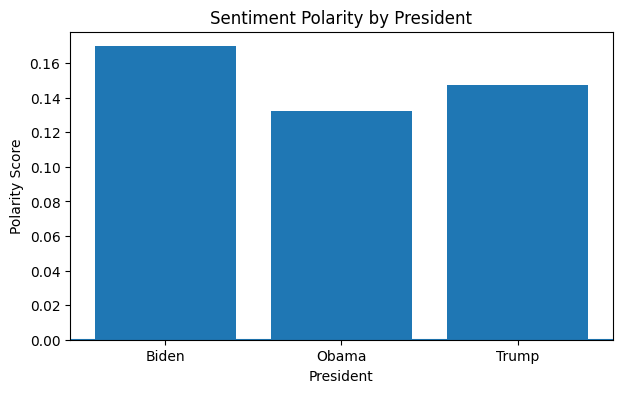

In [44]:
plt.figure(figsize=(7, 4))
plt.bar(sentiment_df["president"], sentiment_df["polarity"])
plt.title("Sentiment Polarity by President")
plt.xlabel("President")
plt.ylabel("Polarity Score")
plt.axhline(0)
plt.show()

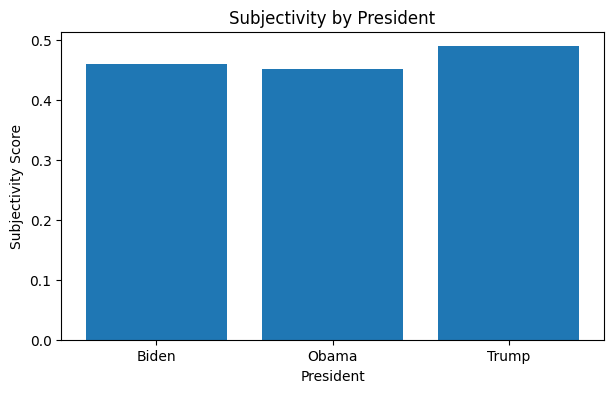

In [45]:
plt.figure(figsize=(7, 4))
plt.bar(sentiment_df["president"], sentiment_df["subjectivity"])
plt.title("Subjectivity by President")
plt.xlabel("President")
plt.ylabel("Subjectivity Score")
plt.show()

In [46]:
pronouns = ["i", "we", "our", "us", "you", "they", "them", "my"]

def pronoun_analysis(text):
    words = text.split()
    total_words = len(words)
    word_counts = Counter(words)

    result = {}

    for pronoun in pronouns:
        count = word_counts[pronoun]
        normalized_count = (count / total_words) * 1000 if total_words > 0 else 0
        result[pronoun] = normalized_count

    return result


pronoun_results = []

for _, row in df.iterrows():
    scores = pronoun_analysis(row["clean_speech"])
    scores["president"] = row["president"]
    pronoun_results.append(scores)

pronoun_df = pd.DataFrame(pronoun_results)
pronoun_df = pronoun_df[["president"] + pronouns]
pronoun_df

,president,i,we,our,us,you,they,them,my
0,Biden,17.001546,36.707883,16.228748,10.046368,9.273570,3.091190,1.159196,10.046368
1,Obama,1.864802,31.701632,35.431235,9.790210,2.331002,4.662005,0.000000,1.398601
2,Trump,12.405238,29.979325,24.465886,0.689180,5.168849,3.445899,0.344590,5.168849


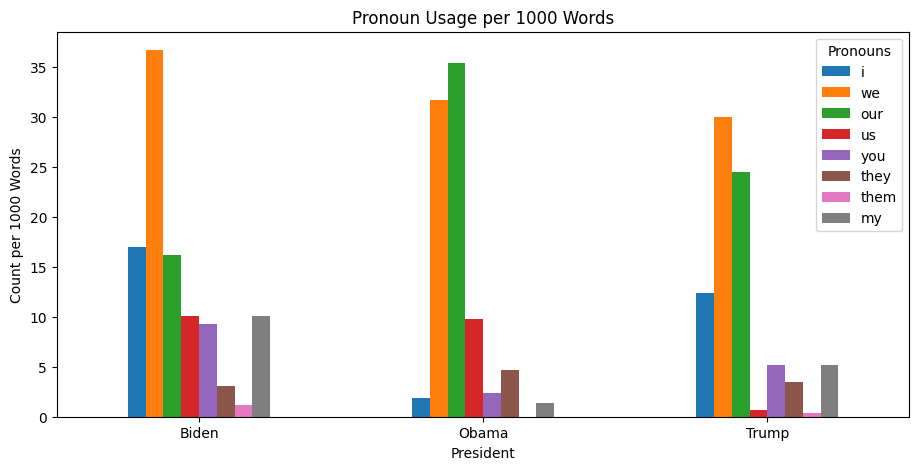

In [47]:
pronoun_plot_df = pronoun_df.set_index("president")

pronoun_plot_df.plot(kind="bar", figsize=(11, 5))
plt.title("Pronoun Usage per 1000 Words")
plt.xlabel("President")
plt.ylabel("Count per 1000 Words")
plt.xticks(rotation=0)
plt.legend(title="Pronouns")
plt.show()

In [48]:
import textstat

def readability_scores(text):
    return pd.Series({
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
        "flesch_kincaid_grade": textstat.flesch_kincaid_grade(text),
        "gunning_fog": textstat.gunning_fog(text)
    })

readability_df = df["speech"].apply(readability_scores)
readability_df.insert(0, "president", df["president"])
readability_df

,president,flesch_reading_ease,flesch_kincaid_grade,gunning_fog
0,Biden,70.028271,7.018628,8.828632
1,Obama,52.279704,11.971973,13.504571
2,Trump,56.012800,9.379198,10.996915


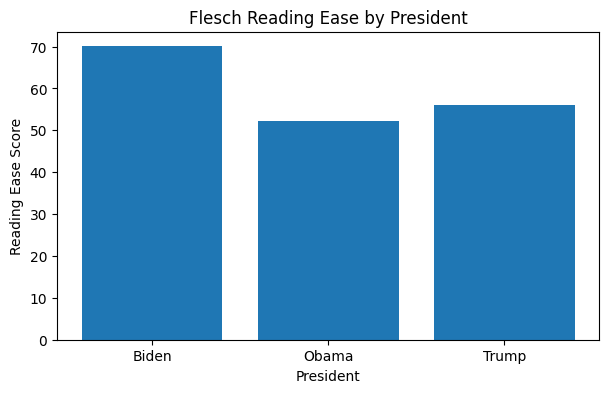

In [49]:
plt.figure(figsize=(7, 4))
plt.bar(readability_df["president"], readability_df["flesch_reading_ease"])
plt.title("Flesch Reading Ease by President")
plt.xlabel("President")
plt.ylabel("Reading Ease Score")
plt.show()

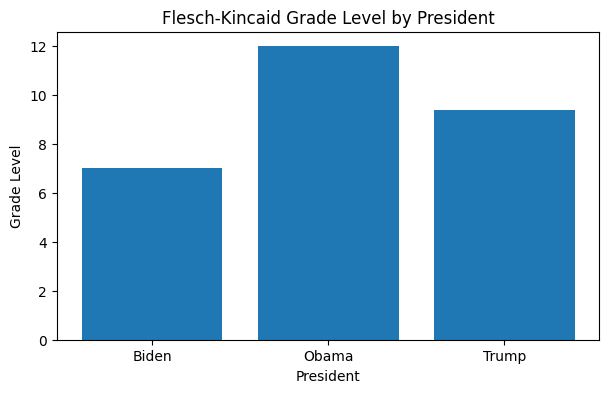

In [50]:
plt.figure(figsize=(7, 4))
plt.bar(readability_df["president"], readability_df["flesch_kincaid_grade"])
plt.title("Flesch-Kincaid Grade Level by President")
plt.xlabel("President")
plt.ylabel("Grade Level")
plt.show()

In [51]:
phrase_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=500,
    ngram_range=(2, 3)
)

phrase_matrix = phrase_vectorizer.fit_transform(df["clean_speech"])
phrase_features = phrase_vectorizer.get_feature_names_out()

phrase_df = pd.DataFrame(
    phrase_matrix.toarray(),
    columns=phrase_features,
    index=df["president"]
)

def get_top_phrases(president_name, top_n=10):
    row = phrase_df.loc[president_name]
    top_phrases = row.sort_values(ascending=False).head(top_n)

    return pd.DataFrame({
        "phrase": top_phrases.index,
        "tfidf_score": top_phrases.values
    })

for president in df["president"]:
    print("\nPresident:", president)
    display(get_top_phrases(president, 10))


President: Biden


,phrase,tfidf_score
0,fellow americans,0.273803
1,common objects,0.180009
2,american story,0.180009
3,objects love,0.120006
4,ve come,0.120006
5,today tomorrow,0.120006
6,racial justice,0.120006
7,silent prayer,0.120006
8,sound like,0.120006
9,defined common,0.120006



President: Obama


,phrase,tfidf_score
0,journey complete,0.294956
1,applause journey,0.235965
2,applause journey complete,0.235965
3,people believe,0.176974
4,created equal,0.134593
5,liberty pursuit,0.117982
6,meaning creed,0.117982
7,liberty pursuit happiness,0.117982
8,new jobs,0.117982
9,just guided,0.117982



President: Trump


,phrase,tfidf_score
0,united states,0.284535
1,panama canal,0.180660
2,common sense,0.120440
3,going bring,0.120440
4,golden age,0.120440
5,manufacturing nation,0.120440
6,los angeles,0.120440
7,immense power,0.120440
8,nation like,0.120440
9,peacemaker unifier,0.120440


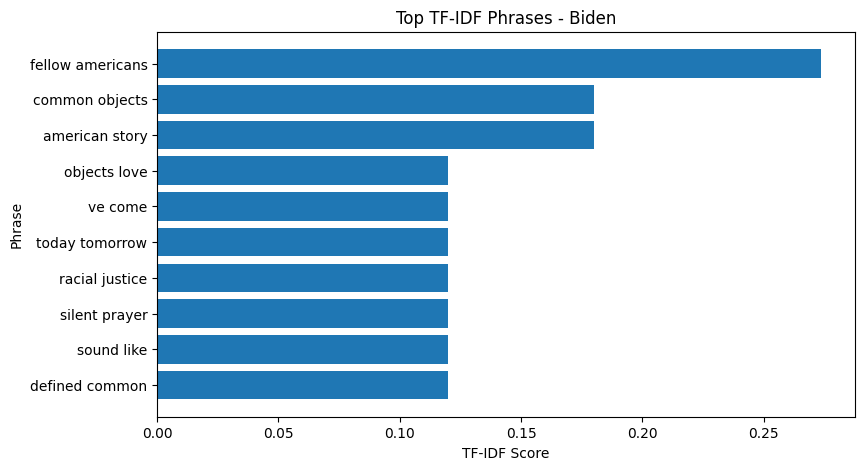

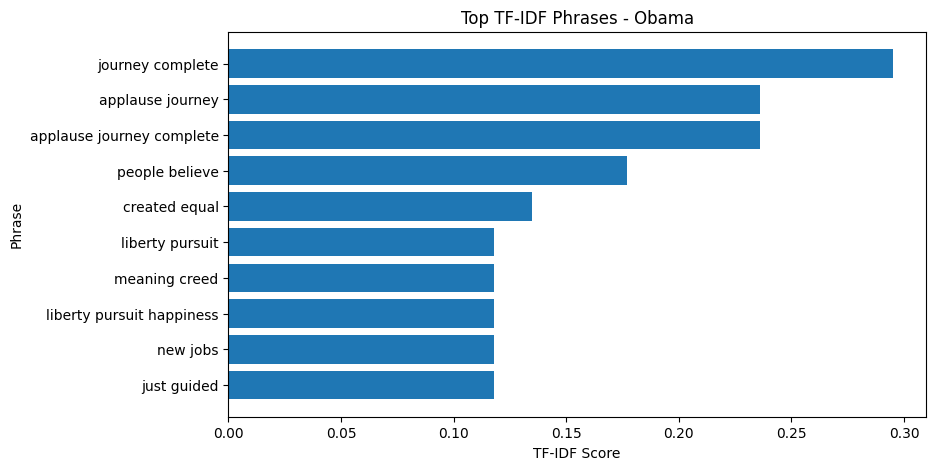

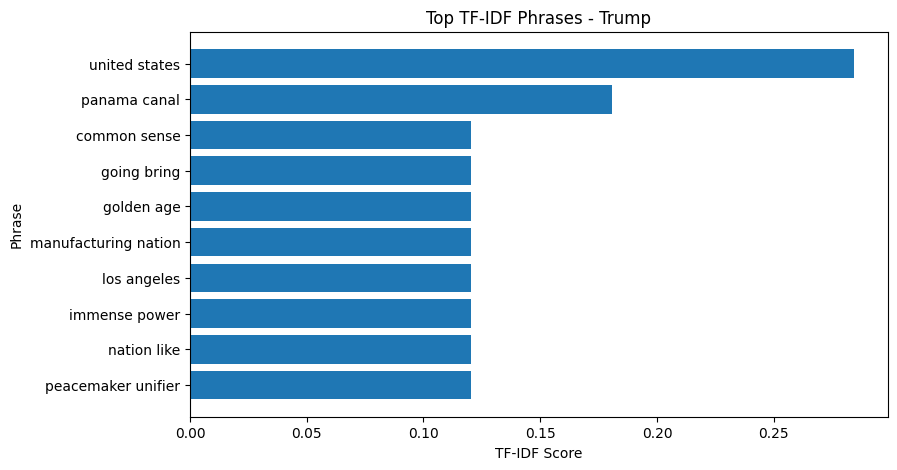

In [52]:
for president in df["president"]:
    top_phrases_df = get_top_phrases(president, 10)

    plt.figure(figsize=(9, 5))
    plt.barh(top_phrases_df["phrase"], top_phrases_df["tfidf_score"])
    plt.title(f"Top TF-IDF Phrases - {president}")
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Phrase")
    plt.gca().invert_yaxis()
    plt.show()

In [53]:
final_summary = stats_df.merge(sentiment_df, on="president")
final_summary = final_summary.merge(readability_df, on="president")

final_summary

,president,word_count,sentence_count,unique_words,avg_sentence_length,lexical_diversity,polarity,subjectivity,flesch_reading_ease,flesch_kincaid_grade,gunning_fog
0,Biden,3058.0,186.0,737.0,16.440860,0.241007,0.169690,0.460089,70.028271,7.018628,8.828632
1,Obama,2447.0,88.0,768.0,27.806818,0.313854,0.132527,0.451320,52.279704,11.971973,13.504571
2,Trump,3268.0,182.0,924.0,17.956044,0.282742,0.147635,0.489194,56.012800,9.379198,10.996915


In [54]:
top_keywords_summary = []

for president in df["president"]:
    top_words = get_top_tfidf_words(president, 10)["word_or_phrase"].tolist()
    top_phrases = get_top_phrases(president, 5)["phrase"].tolist()

    top_keywords_summary.append({
        "president": president,
        "top_tfidf_words": ", ".join(top_words),
        "top_tfidf_phrases": ", ".join(top_phrases)
    })

top_keywords_df = pd.DataFrame(top_keywords_summary)

final_summary = final_summary.merge(top_keywords_df, on="president")
final_summary

,president,word_count,sentence_count,unique_words,avg_sentence_length,lexical_diversity,polarity,subjectivity,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,top_tfidf_words,top_tfidf_phrases
0,Biden,3058.0,186.0,737.0,16.440860,0.241007,0.169690,0.460089,70.028271,7.018628,8.828632,"america, story, nation, days, americans, peopl...","fellow americans, common objects, american sto..."
1,Obama,2447.0,88.0,768.0,27.806818,0.313854,0.132527,0.451320,52.279704,11.971973,13.504571,"applause, people, generation, time, journey co...","journey complete, applause journey, applause j..."
2,Trump,3268.0,182.0,924.0,17.956044,0.282742,0.147635,0.489194,56.012800,9.379198,10.996915,"america, nation, country, government, american...","united states, panama canal, common sense, goi..."


In [55]:
final_summary.to_csv("final_presidential_speech_nlp_summary.csv", index=False)
theme_df.to_csv("theme_analysis.csv", index=False)
pronoun_df.to_csv("pronoun_analysis.csv", index=False)
similarity_df.to_csv("cosine_similarity.csv")

files.download("final_presidential_speech_nlp_summary.csv")
files.download("theme_analysis.csv")
files.download("pronoun_analysis.csv")
files.download("cosine_similarity.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>